 # Extract the Uttarakhand State Boundary

 Filters the state out of a national GADM admin-boundary shapefile and

 saves it as a standalone shapefile for use in the data collection pipeline.

In [1]:
# =====================================================================
# CONFIG
# =====================================================================
import os

GADM_SHAPEFILE = os.environ.get(
    "FFP_GADM_SHAPEFILE", r"C:\Users\khush\Downloads\Mobile Devices\IND_adm (1)\IND_adm1.shp"
)
OUTPUT_SHAPEFILE = os.environ.get(
    "FFP_BOUNDARY_OUTPUT", r"C:\Users\khush\ForestFireProject\gis_data\raw\uttarakhand_boundary.shp"
)


In [2]:
import geopandas as gpd

# GADM shapefiles are sometimes missing their .shx index — this forces
# geopandas to rebuild it instead of failing to load.
os.environ["SHAPE_RESTORE_SHX"] = "YES"

india_states = gpd.read_file(GADM_SHAPEFILE)
print(india_states.columns)  # state name column varies by GADM version, usually 'NAME_1'


Index(['ID_0', 'ISO', 'NAME_0', 'ID_1', 'NAME_1', 'TYPE_1', 'ENGTYPE_1',
       'NL_NAME_1', 'VARNAME_1', 'geometry'],
      dtype='str')


In [3]:
# Confirm the exact spelling used in this shapefile before filtering
print(india_states["NAME_1"].unique())


<ArrowStringArray>
[   'Andaman and Nicobar',         'Andhra Pradesh',      'Arunachal Pradesh',
                  'Assam',                  'Bihar',             'Chandigarh',
           'Chhattisgarh', 'Dadra and Nagar Haveli',          'Daman and Diu',
                  'Delhi',                    'Goa',                'Gujarat',
                'Haryana',       'Himachal Pradesh',      'Jammu and Kashmir',
              'Jharkhand',              'Karnataka',                 'Kerala',
            'Lakshadweep',         'Madhya Pradesh',            'Maharashtra',
                'Manipur',              'Meghalaya',                'Mizoram',
               'Nagaland',                 'Orissa',             'Puducherry',
                 'Punjab',              'Rajasthan',                 'Sikkim',
             'Tamil Nadu',              'Telangana',                'Tripura',
          'Uttar Pradesh',            'Uttaranchal',            'West Bengal']
Length: 36, dtype: str


(1, 10)


<Axes: >

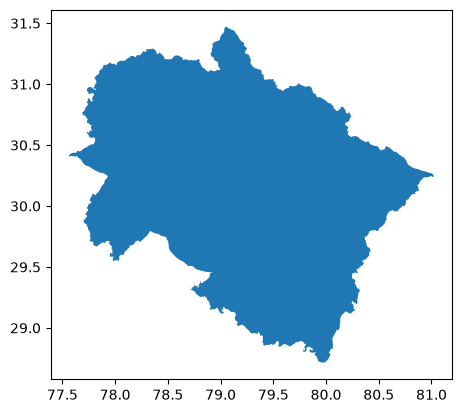

In [4]:
# GADM labels the state 'Uttaranchal' (its pre-2007 name), not 'Uttarakhand'
uttarakhand = india_states[india_states["NAME_1"] == "Uttaranchal"]

print(uttarakhand.shape)  # should be exactly 1 row
uttarakhand.plot()  # visual sanity check


In [5]:
os.makedirs(os.path.dirname(OUTPUT_SHAPEFILE), exist_ok=True)
uttarakhand.to_file(OUTPUT_SHAPEFILE)
print("Saved boundary to:", OUTPUT_SHAPEFILE)


Saved boundary to: C:\Users\khush\ForestFireProject\gis_data\raw\uttarakhand_boundary.shp
